# Deep Learning-based HR Estimation from PPG and Accelerometer data

In this notebook, a classical approach is taken to estimate HR from the DaLiA PPG dataset.

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import subprocess
import atexit

%matplotlib widget
plt.close('all')

# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


In [2]:
# Load data

PREPROC_PATH = "/Volumes/LPM02 storage/Datasets/Bio/DaLiA/data/data_preproc_fs32.pkl"

with open(PREPROC_PATH, 'rb') as f:
    preproc = pkl.load(f)

data_preproc = preproc['data']
params       = preproc['params']

# Unpack params as module-level constants
FS        = params['FS']
BPF_FC1   = params['BPF_FC1']
BPF_FC2   = params['BPF_FC2']
BPF_ORDER = params['BPF_ORDER']
T_WIN     = params['T_WIN']
T_STRIDE  = params['T_STRIDE']
N_WIN     = params['N_WIN']
N_STRIDE  = params['N_STRIDE']

print("Loaded preprocessed data")
print(f"  Subjects : {list(data_preproc.keys())}")
print(f"  FS       : {FS} Hz")
print(f"  BPF      : {BPF_FC1}–{BPF_FC2} Hz, order {BPF_ORDER}")
print(f"  Window   : {T_WIN}s, stride {T_STRIDE}s ({N_WIN} samples, {N_STRIDE} stride)")
for subj_id, d in data_preproc.items():
    print(f"  {subj_id} — ppg: {d['ppg'].shape}, acc: {d['acc'].shape}, labels: {d['label'].shape}")

Loaded preprocessed data
  Subjects : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
  FS       : 32 Hz
  BPF      : 0.4–4.0 Hz, order 4
  Window   : 8.0s, stride 2.0s (256 samples, 64 stride)
  S1 — ppg: (4603, 256, 1), acc: (4603, 256, 3), labels: (4603,)
  S2 — ppg: (4099, 256, 1), acc: (4099, 256, 3), labels: (4099,)
  S3 — ppg: (4367, 256, 1), acc: (4367, 256, 3), labels: (4367,)
  S4 — ppg: (4572, 256, 1), acc: (4572, 256, 3), labels: (4572,)
  S5 — ppg: (4649, 256, 1), acc: (4649, 256, 3), labels: (4649,)
  S6 — ppg: (2622, 256, 1), acc: (2622, 256, 3), labels: (2622,)
  S7 — ppg: (4668, 256, 1), acc: (4668, 256, 3), labels: (4668,)
  S8 — ppg: (4037, 256, 1), acc: (4037, 256, 3), labels: (4037,)
  S9 — ppg: (4277, 256, 1), acc: (4277, 256, 3), labels: (4277,)
  S10 — ppg: (5321, 256, 1), acc: (5321, 256, 3), labels: (5321,)
  S11 — ppg: (4521, 256, 1), acc: (4521, 256, 3), labels: (4521,)
  S12 — ppg: (3954, 256, 1), acc: (3954,

## HR Normalization

We need to normalize heart rate for eventual prediction but also for injection of previous heart rate as a late model input. Use min-max normalization. 

In [3]:
# Normalization of heart rate data

# Extreme HRs (BPF extents)
HR_MIN_NORM = 24.0
HR_MAX_NORM = 240.0

def normalize_hr(hr, hr_min=HR_MIN_NORM, hr_max=HR_MAX_NORM):
    return (hr - hr_min) / (hr_max - hr_min)

def denormalize_hr(hr_norm, hr_min=HR_MIN_NORM, hr_max=HR_MAX_NORM):
    return hr_norm * (hr_max - hr_min) + hr_min

In [4]:
# Dataset and DataLoaders

class PPGDataset(Dataset):
    """
    PyTorch Dataset for PPG-DaLiA windows.

    Each example contains:
        x:       (N_WIN, 4)  — PPG + ACC x/y/z, z-score normalized
        hr:      scalar      — ground truth HR normalized to [0, 1]
        hr_prev: scalar      — previous window HR normalized to [0, 1]

        hr_prev for first window of each subject = 0 (consistent with dropout that will mimick this anyway)

    Args:
        data_preproc: dict of preprocessed subject data
        subject_ids:  list of subject IDs to include
    """

    def __init__(self, data_preproc, subject_ids):
        self.samples = []  # list of (x, hr, hr_prev) tuples

        for subj_id in subject_ids:
            d        = data_preproc[subj_id]
            ppg      = d['ppg']   # (n_windows, N_WIN, 1)
            acc      = d['acc']   # (n_windows, N_WIN, 3)
            labels   = d['label'] # (n_windows,)
            n_windows = ppg.shape[0]

            # Normalize HR labels to [0, 1]
            labels_norm = normalize_hr(labels)

            # Precompute hr_prev: label[i-1] for i > 0, 0 for i = 0
            hr_prev_norm = np.empty(n_windows)
            hr_prev_norm[0]  = 0.0
            hr_prev_norm[1:] = labels_norm[:-1]

            for i in range(n_windows):
                # Concatenate PPG and ACC along channel dim → (N_WIN, 4)
                x = np.concatenate([ppg[i], acc[i]], axis=1).astype(np.float32)

                hr      = np.float32(labels_norm[i])
                hr_prev = np.float32(hr_prev_norm[i])

                self.samples.append((x, hr, hr_prev))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, hr, hr_prev = self.samples[idx]
        return (
            torch.tensor(x),
            torch.tensor(hr),
            torch.tensor(hr_prev),
        )


# Train/val split — leave-one-subject-out (LOSO)
# Hold out S1 as validation subject for now; rotate in full eval
VAL_SUBJECT  = 'S1'
all_subjects = list(data_preproc.keys())
train_subjects = [s for s in all_subjects if s != VAL_SUBJECT]

train_dataset = PPGDataset(data_preproc, train_subjects)
val_dataset   = PPGDataset(data_preproc, [VAL_SUBJECT])

print(f"Train windows: {len(train_dataset)}")
print(f"Val windows:   {len(val_dataset)}")

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Verify a batch
x_batch, hr_batch, hr_prev_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  x:       {x_batch.shape}")
print(f"  hr:      {hr_batch.shape}")
print(f"  hr_prev: {hr_prev_batch.shape}")

Train windows: 60094
Val windows:   4603

Train batches: 939
Val batches:   72

Sample batch shapes:
  x:       torch.Size([64, 256, 4])
  hr:      torch.Size([64])
  hr_prev: torch.Size([64])


In [5]:
# Model hyperparameters

CONV1_FILTERS   = 48
CONV1_KERNEL    = 11
CONV1_POOL      = 2

CONV2_FILTERS   = 96
CONV2_KERNEL    = 5
CONV2_POOL      = 2

LSTM_UNITS      = 96      # per direction — bidirectional doubles to 192

FC_UNITS        = 32

HR_NOISE_STD_BPM = 5.0
HR_PREV_DROPOUT   = 0.10

# --------------------------------------------
N_CHANNELS      = 4       # PPG + ACC x/y/z
N_WIN           = 256     # samples per window
HR_NOISE_STD_NORM = HR_NOISE_STD_BPM / (HR_MAX_NORM - HR_MIN_NORM)  # ~0.023

In [6]:
# Model definition and instantiation

class PPGHeartRateModel(nn.Module):
    def __init__(self):
        super(PPGHeartRateModel, self).__init__()

        # Conv block 1
        self.conv1 = nn.Conv1d(
            in_channels  = N_CHANNELS,
            out_channels = CONV1_FILTERS,
            kernel_size  = CONV1_KERNEL,
            stride       = 1,
            padding      = CONV1_KERNEL // 2,  # 'same' padding approximation
        )
        self.bn1   = nn.BatchNorm1d(CONV1_FILTERS)
        self.pool1 = nn.AvgPool1d(kernel_size=CONV1_POOL, stride=CONV1_POOL)

        # Conv block 2
        self.conv2 = nn.Conv1d(
            in_channels  = CONV1_FILTERS,
            out_channels = CONV2_FILTERS,
            kernel_size  = CONV2_KERNEL,
            stride       = 1,
            padding      = CONV2_KERNEL // 2,  # 'same' padding approximation
        )
        self.bn2   = nn.BatchNorm1d(CONV2_FILTERS)
        self.pool2 = nn.AvgPool1d(kernel_size=CONV2_POOL, stride=CONV2_POOL)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size    = CONV2_FILTERS,
            hidden_size   = LSTM_UNITS,
            num_layers    = 1,
            batch_first   = True,
            bidirectional = True,
        )

        # hr_prev processing
        self.hr_prev_dropout = nn.Dropout(p=HR_PREV_DROPOUT)

        # Dense head
        # GAP output: LSTM_UNITS * 2 (bidirectional)
        # hr_prev: 1
        # total input to fc1: LSTM_UNITS * 2 + 1
        self.fc1    = nn.Linear(LSTM_UNITS * 2 + 1, FC_UNITS)
        self.relu   = nn.ReLU()
        self.output = nn.Linear(FC_UNITS, 1)

    def forward(self, x, hr_prev):
        """
        Args:
            x:       (batch, N_WIN, N_CHANNELS) — PPG + ACC windows
            hr_prev: (batch,)                   — normalized previous HR
        """

        # Conv1d expects (batch, channels, time)
        # permute from (batch, time, channels) → (batch, channels, time)
        x = x.permute(0, 2, 1)

        # Conv block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        # Conv block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        # LSTM expects (batch, time, channels)
        # permute from (batch, channels, time) → (batch, time, channels)
        x = x.permute(0, 2, 1)

        # Bidirectional LSTM — return_sequences=True equivalent
        x, _ = self.lstm(x)   # x: (batch, time, LSTM_UNITS * 2)

        # Global average pooling across time dimension
        x = x.mean(dim=1)     # (batch, LSTM_UNITS * 2)

        # hr_prev processing: add gaussian noise during training, then dropout
        if self.training:
            hr_prev = hr_prev + torch.randn_like(hr_prev) * HR_NOISE_STD_NORM
            hr_prev = hr_prev.clamp(0.0, 1.0)
        hr_prev = self.hr_prev_dropout(hr_prev)

        # Reshape hr_prev for concatenation: (batch,) → (batch, 1)
        hr_prev = hr_prev.unsqueeze(1)

        # Concatenate GAP output and hr_prev
        x = torch.cat([x, hr_prev], dim=1)   # (batch, LSTM_UNITS * 2 + 1)

        # Dense head
        x = self.fc1(x)
        x = self.relu(x)
        x = self.output(x)    # (batch, 1)

        return x.squeeze(1)   # (batch,)


# Instantiate and move to device
model = PPGHeartRateModel().to(device)
print(model)

PPGHeartRateModel(
  (conv1): Conv1d(4, 48, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (conv2): Conv1d(48, 96, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (lstm): LSTM(96, 96, batch_first=True, bidirectional=True)
  (hr_prev_dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=193, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
# Training loop parameters and methods

N_EPOCHS    = 100
LR          = 1e-3
MIN_LR      = 1e-5
LR_PATIENCE = 5      # epochs of no improvement before LR reduction
LR_FACTOR   = 0.5    # LR multiplied by this on plateau
ES_PATIENCE = 25     # early stopping patience

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for x, hr, hr_prev in loader:
        x       = x.to(device)
        hr      = hr.to(device)
        hr_prev = hr_prev.to(device)

        optimizer.zero_grad()
        hr_pred = model(x, hr_prev)
        loss    = torch.mean(torch.abs(hr_pred - hr))  # MAE in normalized space
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def val_epoch(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for x, hr, hr_prev in loader:
            x       = x.to(device)
            hr      = hr.to(device)
            hr_prev = hr_prev.to(device)

            hr_pred = model(x, hr_prev)
            all_preds.append(hr_pred.cpu())
            all_labels.append(hr.cpu())

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    mae_norm   = torch.mean(torch.abs(all_preds - all_labels)).item()
    mae_bpm    = mae_norm * (HR_MAX_NORM - HR_MIN_NORM)
    return mae_bpm

In [8]:
# # Training loop — single held-out subject (S1)


# optimizer = optim.Adam(model.parameters(), lr=LR)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode     = 'min',
#     factor   = LR_FACTOR,
#     patience = LR_PATIENCE,
#     min_lr   = MIN_LR,
# )





# # Prevent sleep during training
# print('Preventing sleep during training...')
# _caffeinate = subprocess.Popen(['caffeinate', '-i'])

# # Ensure it's killed even if training crashes
# atexit.register(_caffeinate.terminate)


# # Training loop
# best_val_mae   = float('inf')
# best_weights   = None
# epochs_no_imp  = 0
# train_mae_history = []
# val_mae_history   = []

# for epoch in range(1, N_EPOCHS + 1):
#     train_loss = train_epoch(model, train_loader, optimizer, device)
#     val_mae    = val_epoch(model, val_loader, device)

#     train_mae_bpm = train_loss * (HR_MAX_NORM - HR_MIN_NORM)

#     train_mae_history.append(train_mae_bpm)
#     val_mae_history.append(val_mae)

#     scheduler.step(val_mae)
#     current_lr = optimizer.param_groups[0]['lr']

#     print(f"Epoch {epoch:>3}/{N_EPOCHS} | "
#           f"Train MAE: {train_mae_bpm:>6.2f} BPM | "
#           f"Val MAE: {val_mae:>6.2f} BPM | "
#           f"LR: {current_lr:.2e}")

#     if val_mae < best_val_mae:
#         best_val_mae  = val_mae
#         best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#         epochs_no_imp = 0
#     else:
#         epochs_no_imp += 1
#         if epochs_no_imp >= ES_PATIENCE:
#             print(f"\nEarly stopping at epoch {epoch} — "
#                   f"no improvement for {ES_PATIENCE} epochs")
#             break

# # Restore best weights
# if best_weights is not None:
#     model.load_state_dict(best_weights)
#     print(f"\nBest val MAE: {best_val_mae:.2f} BPM")
# else:
#     print("\nWarning: no valid checkpoint found — model weights not restored")


# # Re-enable sleep
# _caffeinate.terminate()
# print("Sleep re-enabled")

# # Plot loss
# fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(train_mae_history, lw=1.5, color='steelblue', label='Train MAE')
# ax.plot(val_mae_history,   lw=1.5, color='tomato',    label='Val MAE')
# ax.axvline(len(val_mae_history) - 1 - epochs_no_imp,
#            color='k', linestyle=':', lw=1.0, label=f'Best val MAE ({best_val_mae:.2f} BPM)')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('MAE (BPM)')
# ax.legend()
# ax.grid(True)
# plt.suptitle(f'Training curves — Val subject: {VAL_SUBJECT}')
# plt.show()

In [9]:
# Full LOSO evaluation

# Prevent sleep during training
print('Preventing sleep during training...')
_caffeinate = subprocess.Popen(['caffeinate', '-ids'])

# Ensure it's killed even if training crashes
atexit.register(_caffeinate.terminate)

loso_results = {}

for val_subject in all_subjects:
    print(f"\n{'='*60}")
    print(f"Fold: val subject = {val_subject}")
    print(f"{'='*60}")

    # Dataset and loaders for this fold
    train_subjects_fold = [s for s in all_subjects if s != val_subject]
    train_dataset_fold  = PPGDataset(data_preproc, train_subjects_fold)
    val_dataset_fold    = PPGDataset(data_preproc, [val_subject])

    train_loader_fold = DataLoader(train_dataset_fold, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_fold   = DataLoader(val_dataset_fold,   batch_size=BATCH_SIZE, shuffle=False)

    # Fresh model and optimizer for each fold
    model_fold     = PPGHeartRateModel().to(device)
    optimizer_fold = optim.Adam(model_fold.parameters(), lr=LR)
    scheduler_fold = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold,
        mode      = 'min',
        factor    = LR_FACTOR,
        patience  = LR_PATIENCE,
        min_lr    = 1e-5,
    )

    best_val_mae_fold  = float('inf')
    best_weights_fold  = None
    epochs_no_imp_fold = 0
    train_mae_hist     = []
    val_mae_hist       = []

    for epoch in range(1, N_EPOCHS + 1):
        train_loss = train_epoch(model_fold, train_loader_fold, optimizer_fold, device)
        val_mae    = val_epoch(model_fold, val_loader_fold, device)

        train_mae_bpm = train_loss * (HR_MAX_NORM - HR_MIN_NORM)
        train_mae_hist.append(train_mae_bpm)
        val_mae_hist.append(val_mae)

        scheduler_fold.step(val_mae)
        current_lr = optimizer_fold.param_groups[0]['lr']

        print(f"Epoch {epoch:>3}/{N_EPOCHS} | "
              f"Train MAE: {train_mae_bpm:>6.2f} BPM | "
              f"Val MAE: {val_mae:>6.2f} BPM | "
              f"LR: {current_lr:.2e}")

        if val_mae < best_val_mae_fold:
            best_val_mae_fold  = val_mae
            best_weights_fold  = {k: v.cpu().clone()
                                  for k, v in model_fold.state_dict().items()}
            epochs_no_imp_fold = 0
        else:
            epochs_no_imp_fold += 1
            if epochs_no_imp_fold >= ES_PATIENCE:
                print(f"Early stopping at epoch {epoch} — "
                      f"no improvement for {ES_PATIENCE} epochs")
                break

    if best_weights_fold is not None:
        model_fold.load_state_dict(best_weights_fold)

    loso_results[val_subject] = {
        'mae':            best_val_mae_fold,
        'train_mae_hist': train_mae_hist,
        'val_mae_hist':   val_mae_hist,
        'best_epoch':     len(val_mae_hist) - epochs_no_imp_fold,
    }

    print(f"\n{val_subject} best val MAE: {best_val_mae_fold:.2f} BPM")

# Re-enable sleep
_caffeinate.terminate()
print("Sleep re-enabled")

# Summary
maes = [loso_results[s]['mae'] for s in all_subjects]
print(f"\n{'='*60}")
print(f"LOSO Results:")
print(f"{'='*60}")
for s in all_subjects:
    print(f"  {s}: {loso_results[s]['mae']:.2f} BPM")
print(f"\nMean MAE: {np.mean(maes):.2f} BPM")
print(f"Std MAE:  {np.std(maes):.2f} BPM")
print(f"Min MAE:  {np.min(maes):.2f} BPM  ({all_subjects[np.argmin(maes)]})")
print(f"Max MAE:  {np.max(maes):.2f} BPM  ({all_subjects[np.argmax(maes)]})")

Preventing sleep during training...

Fold: val subject = S1
Epoch   1/100 | Train MAE:   9.21 BPM | Val MAE:   5.47 BPM | LR: 1.00e-03
Epoch   2/100 | Train MAE:   5.70 BPM | Val MAE:   4.82 BPM | LR: 1.00e-03
Epoch   3/100 | Train MAE:   5.61 BPM | Val MAE:   4.54 BPM | LR: 1.00e-03
Epoch   4/100 | Train MAE:   5.55 BPM | Val MAE:   4.20 BPM | LR: 1.00e-03
Epoch   5/100 | Train MAE:   5.54 BPM | Val MAE:   4.77 BPM | LR: 1.00e-03
Epoch   6/100 | Train MAE:   5.57 BPM | Val MAE:   3.94 BPM | LR: 1.00e-03
Epoch   7/100 | Train MAE:   5.50 BPM | Val MAE:   4.60 BPM | LR: 1.00e-03
Epoch   8/100 | Train MAE:   5.52 BPM | Val MAE:   4.11 BPM | LR: 1.00e-03
Epoch   9/100 | Train MAE:   5.54 BPM | Val MAE:   4.10 BPM | LR: 1.00e-03
Epoch  10/100 | Train MAE:   5.50 BPM | Val MAE:   3.91 BPM | LR: 1.00e-03
Epoch  11/100 | Train MAE:   5.55 BPM | Val MAE:   4.59 BPM | LR: 1.00e-03
Epoch  12/100 | Train MAE:   5.50 BPM | Val MAE:   3.38 BPM | LR: 1.00e-03
Epoch  13/100 | Train MAE:   5.54 BPM | 

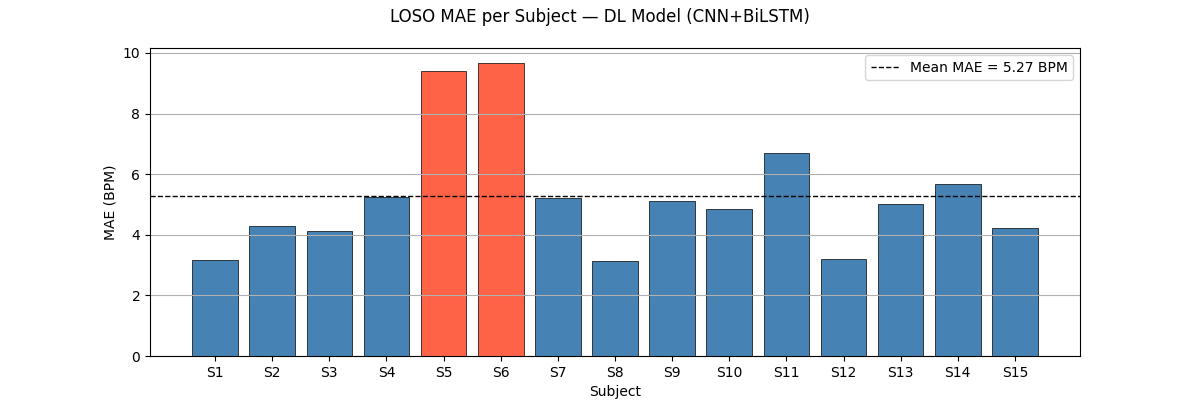

In [10]:
# Per-subject MAE bar chart

subjects = list(loso_results.keys())
maes     = [loso_results[s]['mae'] for s in subjects]
colors   = ['tomato' if m > 7.0 else 'steelblue' for m in maes]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(subjects, maes, color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(np.mean(maes), color='k', linestyle='--', lw=1.0,
           label=f'Mean MAE = {np.mean(maes):.2f} BPM')
ax.set_xlabel('Subject')
ax.set_ylabel('MAE (BPM)')
ax.legend()
ax.grid(True, axis='y')
plt.suptitle('LOSO MAE per Subject — DL Model (CNN+BiLSTM)')
plt.show()

## Why are S5 and S6 significantly higher MAE?

- S6 was known to have had a major hardware issue and thus less data overall (~1.5 hrs), but their data was kept

/var/folders/bq/csqgvczj6jndm459wzs6n4kw0000gn/T/ipykernel_4086/1179169683.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=all_subjects, patch_artist=True,


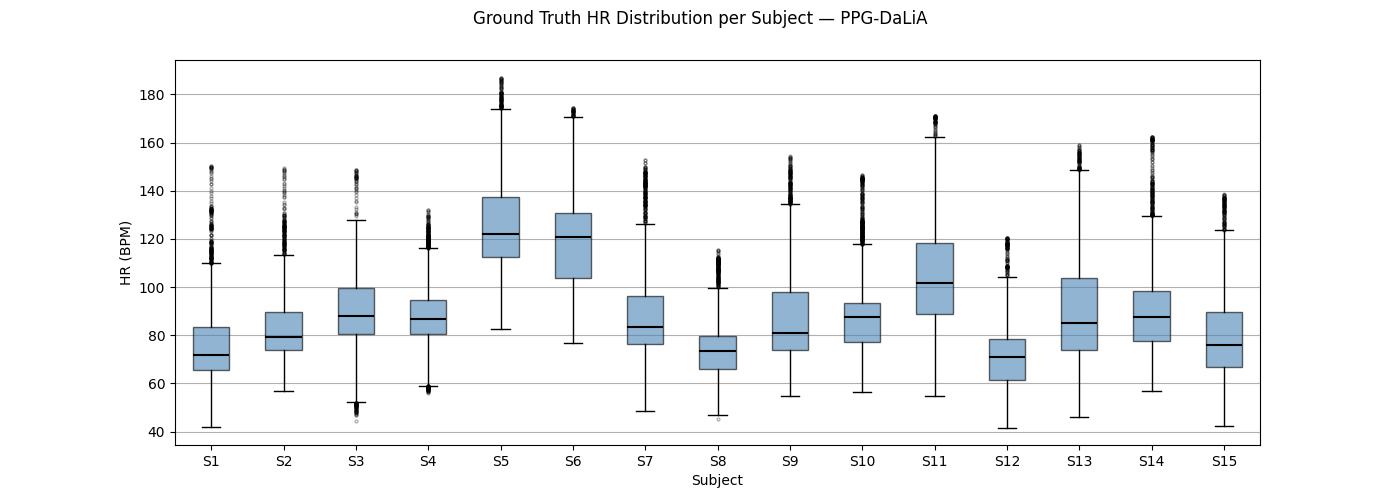

   Subject    Mean HR     Std HR     Min HR     Max HR    N Windows
------------------------------------------------------------
        S1      74.84      16.16      41.86     150.15         4603
        S2      82.49      13.74      56.86     149.25         4099
        S3      89.01      15.85      44.47     148.72         4367
        S4      87.90      12.98      56.16     131.99         4572
        S5     125.84      19.56      82.47     187.02         4649
        S6     119.49      22.32      76.85     174.32         2622
        S7      86.69      18.55      48.63     152.91         4668
        S8      74.27      11.87      45.40     115.50         4037
        S9      87.26      19.95      54.85     154.28         4277
       S10      87.52      15.71      56.35     146.37         5321
       S11     102.67      23.52      54.71     171.09         4521
       S12      71.41      14.81      41.69     120.54         3954
       S13      89.21      22.05      46.05     159.10 

In [12]:
# Ground truth HR distribution per subject — box and whisker

fig, ax = plt.subplots(figsize=(14, 5))

data    = [data_preproc[s]['label'] for s in all_subjects]
ax.boxplot(data, labels=all_subjects, patch_artist=True,
           boxprops    = dict(facecolor='steelblue', alpha=0.6),
           medianprops = dict(color='k', lw=1.5),
           flierprops  = dict(marker='o', markersize=2, alpha=0.3))

ax.set_xlabel('Subject')
ax.set_ylabel('HR (BPM)')
ax.grid(True, axis='y')
plt.suptitle('Ground Truth HR Distribution per Subject — PPG-DaLiA')
plt.show()

## S5 and S6 followup

- Both distributions are outliers wrt the rest of the subjects (significantly higher mean HR)
- This plus S6 having a truncated dataset make it especially difficult for the model to generalize when either is left out as the validation dataset
- Leaving either or both of these subjects out would pull down MAE

In [13]:
maes_excl = [loso_results[s]['mae'] for s in all_subjects if s not in ['S5', 'S6']]
print(f"Mean MAE excluding S5/S6: {np.mean(maes_excl):.2f} BPM")
print(f"Median MAE all subjects:  {np.median(maes):.2f} BPM")

Mean MAE excluding S5/S6: 4.61 BPM
Median MAE all subjects:  5.03 BPM


## DL Model Results Summary

- CNN+BiLSTM model trained with LOSO CV on PPG-DaLiA (15 subjects)
- Overall LOSO MAE: **5.27 ± 1.93 BPM** (range: 3.12–9.68 BPM)
- Classical spectral subtraction baseline: **19.24 BPM** — (73% MAE reduction)
- Comparable to DeepPPG (Reiss et al. 2019) reported ~4–5 BPM MAE on DaLiA
    - similar performance achieved here with simpler raw time-series architecture vs spectrogram+Ntr stacking approach
- With more time, the following could improve performance:
  - Hyperparameter search (Optuna) over kernel sizes, filter counts, LSTM units
  - Scheduled teacher forcing on hr_prev — reducing train/inference mismatch
  - Data augmentation to address distribution shift for outlier subjects (S5, S6)